In [1]:
import os
import zipfile


extract_path = "lens-finding-test"

for root, dirs, files in os.walk(extract_path):
    print(root, len(files))

lens-finding-test 1
lens-finding-test/train_nonlenses 28675
lens-finding-test/train_lenses 1730
lens-finding-test/test_lenses 195
lens-finding-test/test_nonlenses 19455


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Change this path
DATA_DIR = "lens-finding-test"

train_lens_dir = os.path.join(DATA_DIR, "train_lenses")
train_nonlens_dir = os.path.join(DATA_DIR, "train_nonlenses")

# Pick one sample
sample_file = os.listdir(train_lens_dir)[0]
sample_path = os.path.join(train_lens_dir, sample_file)

img = np.load(sample_path)

print("Shape:", img.shape)  # should be (3, 64, 64)

Shape: (3, 64, 64)


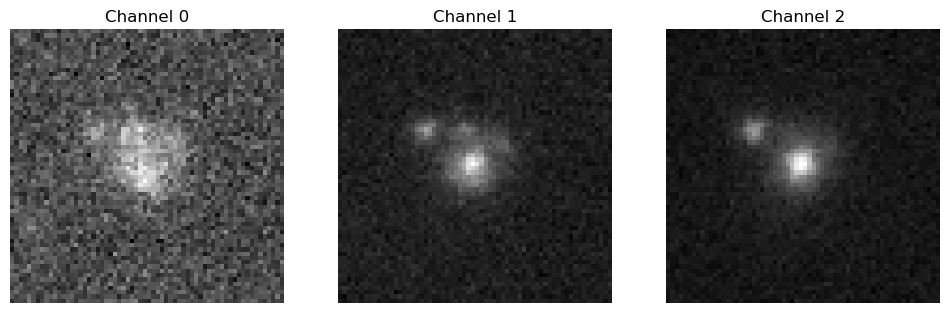

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(img[i], cmap="gray")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.show()

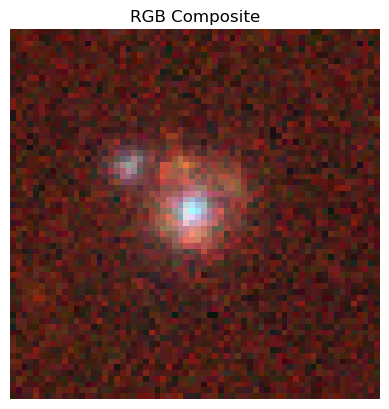

In [4]:
def make_rgb(img):
    # Normalize per channel
    rgb = np.zeros((64, 64, 3))
    for i in range(3):
        channel = img[i]
        channel = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
        rgb[:, :, i] = channel
    return rgb

rgb_img = make_rgb(img)

plt.imshow(rgb_img)
plt.title("RGB Composite")
plt.axis("off")
plt.show()

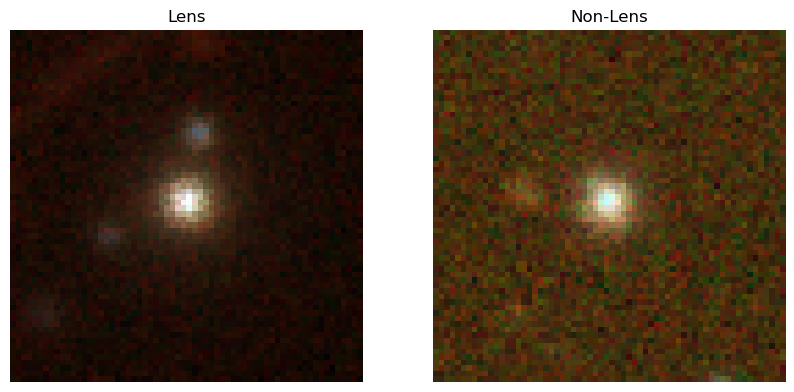

In [5]:
def load_random_sample(folder):
    file = np.random.choice(os.listdir(folder))
    return np.load(os.path.join(folder, file))

lens_img = load_random_sample(train_lens_dir)
nonlens_img = load_random_sample(train_nonlens_dir)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(make_rgb(lens_img))
axes[0].set_title("Lens")
axes[0].axis("off")

axes[1].imshow(make_rgb(nonlens_img))
axes[1].set_title("Non-Lens")
axes[1].axis("off")

plt.show()

In [6]:
def compute_stats(folder, n_samples=500):
    means = []
    stds = []
    
    files = os.listdir(folder)[:n_samples]
    
    for f in files:
        img = np.load(os.path.join(folder, f))
        means.append(img.mean())
        stds.append(img.std())
    
    return np.mean(means), np.mean(stds)

lens_mean, lens_std = compute_stats(train_lens_dir)
nonlens_mean, nonlens_std = compute_stats(train_nonlens_dir)

print("Lens     → mean:", lens_mean, "std:", lens_std)
print("Non-lens → mean:", nonlens_mean, "std:", nonlens_std)

Lens     → mean: 0.092447 std: 0.096757114
Non-lens → mean: 0.19584797 std: 0.11934736


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from sklearn.metrics import roc_curve, auc, confusion_matrix

import timm

In [8]:
train_lens_dir = "lens-finding-test/train_lenses"
train_nonlens_dir = "lens-finding-test/train_nonlenses"

test_lens_dir = "lens-finding-test/test_lenses"
test_nonlens_dir = "lens-finding-test/test_nonlenses"

In [9]:
print("Train lenses:", len(os.listdir(train_lens_dir)))
print("Train non-lenses:", len(os.listdir(train_nonlens_dir)))

Train lenses: 1730
Train non-lenses: 28675


In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

mps


In [11]:
def compute_stats(folder, n_samples=500):
    means = []
    stds = []
    
    files = os.listdir(folder)[:n_samples]
    
    for f in files:
        img = np.load(os.path.join(folder, f))
        means.append(img.mean())
        stds.append(img.std())
    
    return np.mean(means), np.mean(stds)

lens_mean, lens_std = compute_stats(train_lens_dir)
nonlens_mean, nonlens_std = compute_stats(train_nonlens_dir)

mean = (lens_mean + nonlens_mean) / 2
std  = (lens_std + nonlens_std) / 2

print("mean:", mean, "std:", std)

mean: 0.14414748549461365 std: 0.10805223882198334


In [12]:
class ToTensor:
    def __call__(self, img):
        return torch.tensor(img, dtype=torch.float32)

In [13]:
train_transform = transforms.Compose([
    ToTensor(),
    transforms.Resize((224,224)),
    transforms.RandomRotation(360),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

val_transform = transforms.Compose([
    ToTensor(),
    transforms.Resize((224,224)),
])

In [14]:
class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir, transform=None):
        self.files = []
        self.labels = []
        self.transform = transform
        
        for f in os.listdir(lens_dir):
            self.files.append(os.path.join(lens_dir, f))
            self.labels.append(1)
            
        for f in os.listdir(nonlens_dir):
            self.files.append(os.path.join(nonlens_dir, f))
            self.labels.append(0)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx])  # (3,64,64)
        
        # Normalize
        img = (img - mean) / std
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

In [15]:
train_dataset = LensDataset(train_lens_dir, train_nonlens_dir, transform=train_transform)
test_dataset  = LensDataset(test_lens_dir, test_nonlens_dir, transform=val_transform)

In [16]:
print(os.listdir("lens-finding-test/"))

['train_nonlenses', '.DS_Store', 'train_lenses', 'test_lenses', 'test_nonlenses']


In [17]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [18]:
num_lens = len(os.listdir(train_lens_dir))
num_nonlens = len(os.listdir(train_nonlens_dir))

pos_weight = torch.tensor([num_nonlens / num_lens]).to(device)
print("pos_weight:", pos_weight)

pos_weight: tensor([16.5751], device='mps:0')


In [19]:
model = timm.create_model(
    'efficientnet_b1',
    pretrained=True,
    in_chans=3,
    num_classes=1
)

model = model.to(device)

In [20]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

In [21]:
from tqdm import tqdm

train_losses = []

epochs = 40

for epoch in range(epochs):
    
    print(f"\nEpoch: {epoch}")
    
    model.train()
    total_train_loss = 0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images).view(-1)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)
    
    scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}")


Epoch: 0


100%|██████████| 476/476 [08:19<00:00,  1.05s/it]


Train Loss: 1.1697

Epoch: 1


100%|██████████| 476/476 [08:29<00:00,  1.07s/it]


Train Loss: 0.4849

Epoch: 2


...

Train Loss: 0.0277

Epoch: 38


100%|██████████| 476/476 [08:09<00:00,  1.03s/it]


Train Loss: 0.0272

Epoch: 39


100%|██████████| 476/476 [08:09<00:00,  1.03s/it]

Train Loss: 0.0256


In [65]:
# Save trained model weights
torch.save(model.state_dict(), "test_V_trained_wts_best.pth")

print("Model weights saved successfully!")

Model weights saved successfully!


In [22]:
def tta_batch(model, images):
    preds = []
    
    for k in range(4):
        rot = torch.rot90(images, k, dims=[2,3])
        preds.append(torch.sigmoid(model(rot)))
        
        flip = torch.flip(rot, dims=[3])
        preds.append(torch.sigmoid(model(flip)))
    
    return torch.mean(torch.stack(preds), dim=0)

In [24]:
model.eval()

y_true = []
y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = tta_batch(model, images).view(-1)
        
        y_scores.extend(outputs.detach().cpu().numpy())
        y_true.extend(labels.detach().cpu().numpy())

In [66]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.3f}")

AUC: 0.990


In [28]:
y_pred = (np.array(y_scores) > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[19233   222]
 [   18   177]]


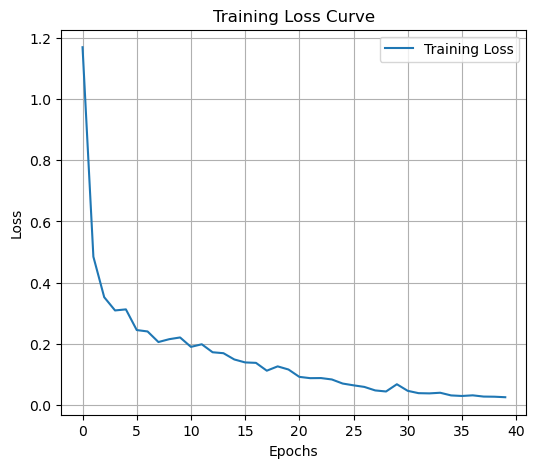

In [67]:
plt.figure(figsize=(6,5))

plt.plot(train_losses, label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid()

plt.show()

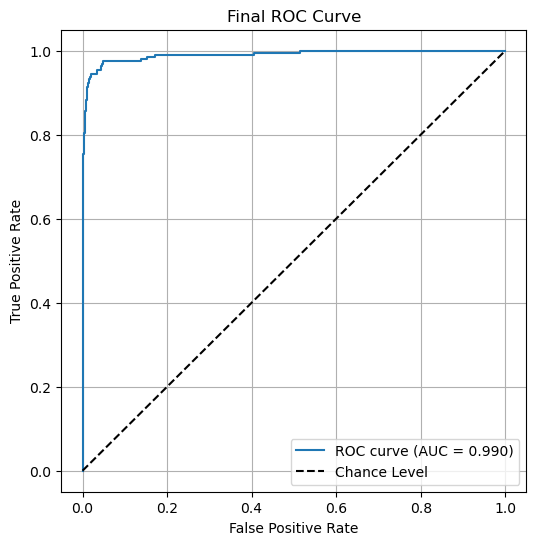

In [70]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'k--', label="Chance Level")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.grid()

plt.show()

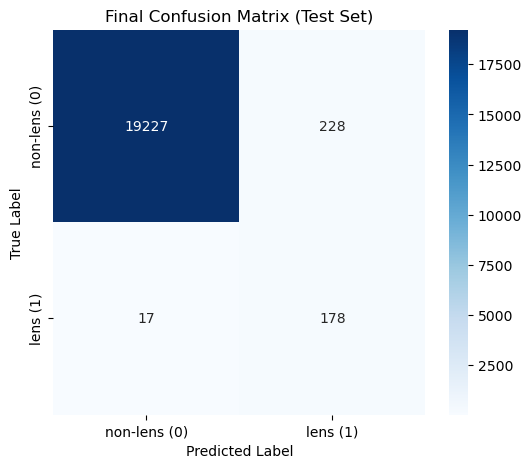

In [71]:
import seaborn as sns

y_pred = (np.array(y_scores) > 0.49).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-lens (0)", "lens (1)"],
            yticklabels=["non-lens (0)", "lens (1)"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix (Test Set)")

plt.show()

In [72]:
from sklearn.metrics import classification_report, accuracy_score

# Convert probabilities → binary predictions
y_pred = (np.array(y_scores) > 0.49).astype(int)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.3f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_true, 
    y_pred,
    target_names=["non-lens (0)", "lens (1)"]
))

Accuracy: 0.988

Classification Report:
              precision    recall  f1-score   support

non-lens (0)       1.00      0.99      0.99     19455
    lens (1)       0.44      0.91      0.59       195

    accuracy                           0.99     19650
   macro avg       0.72      0.95      0.79     19650
weighted avg       0.99      0.99      0.99     19650

